<a href="https://colab.research.google.com/github/Suhrobjonibodullayev/ML-Learning-Journey/blob/main/05_machine_learning_basics/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ai - odamlarga taqlid qiluvchi kamputerlar(dasturlar)

**Machine Learning (ML)** - Kamputerlarni dasturlamagan holda o'z o'zini o'qitish imkonini berish.

ML ishlatiladi:

• Ko'p qonun-qoidalar va shartlar yozishni talab qiladigan
muammolar

• Klassik usul bilan yechim topib bo'lmaydigan kompleks muammolar

• Doimiy o'zgaruvchan muammolar

• Katta o'Ichamdagi ma'lumotlardan yashirin mazmuni va ma'nolarni topishga oid muammolar

1.1 Jarayonni tushunish --> savollar berish orqali

1.2 Analitik yondashuv

1) Qaysi Ml turini tanlaymiz -> Supervised \ Unsupervised \ Reinforestment Learning

2) Muammo turi (Algoritm) -> Regression \ Classification \ Clastering

3) Usul -> online \ offline

Model aniqligini baholash

• MAE - Mean Absolute Error (O'rtacha absolyut xatolik)

• RMSE - Root Mean Square Error (O'rtacha kvadrat xatolik)

# Machine Learning Steps

### Malumotlarni o'rganish

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
# DataFrame bilan tanishuv
URL = "https://github.com/ageron/handson-ml2/blob/master/datasets/housing/housing.csv?raw=true"
df = pd.read_csv(URL)
df.head(7)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY


In [ ]:
df.info() # Ustunlar va ularning dtype larini ko'rish mumkin | Nan qiymatlar bor yoki yo'qligini ko'rish mumkin

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df['ocean_proximity'].value_counts() # ustundagi takrorlanmas qiymatlarni ko'rish

# Index.value_counts(normalize=False, sort=True, ascending=False, bins=None, dropna=True)

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
df.describe() # turli statistikalar | Naodatiy qiymatlar bor yo'qligini ko'rish mumkin -> min / max qiymatlar orqali

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Grafiklar** orqali malumotlarni tahlil qilish

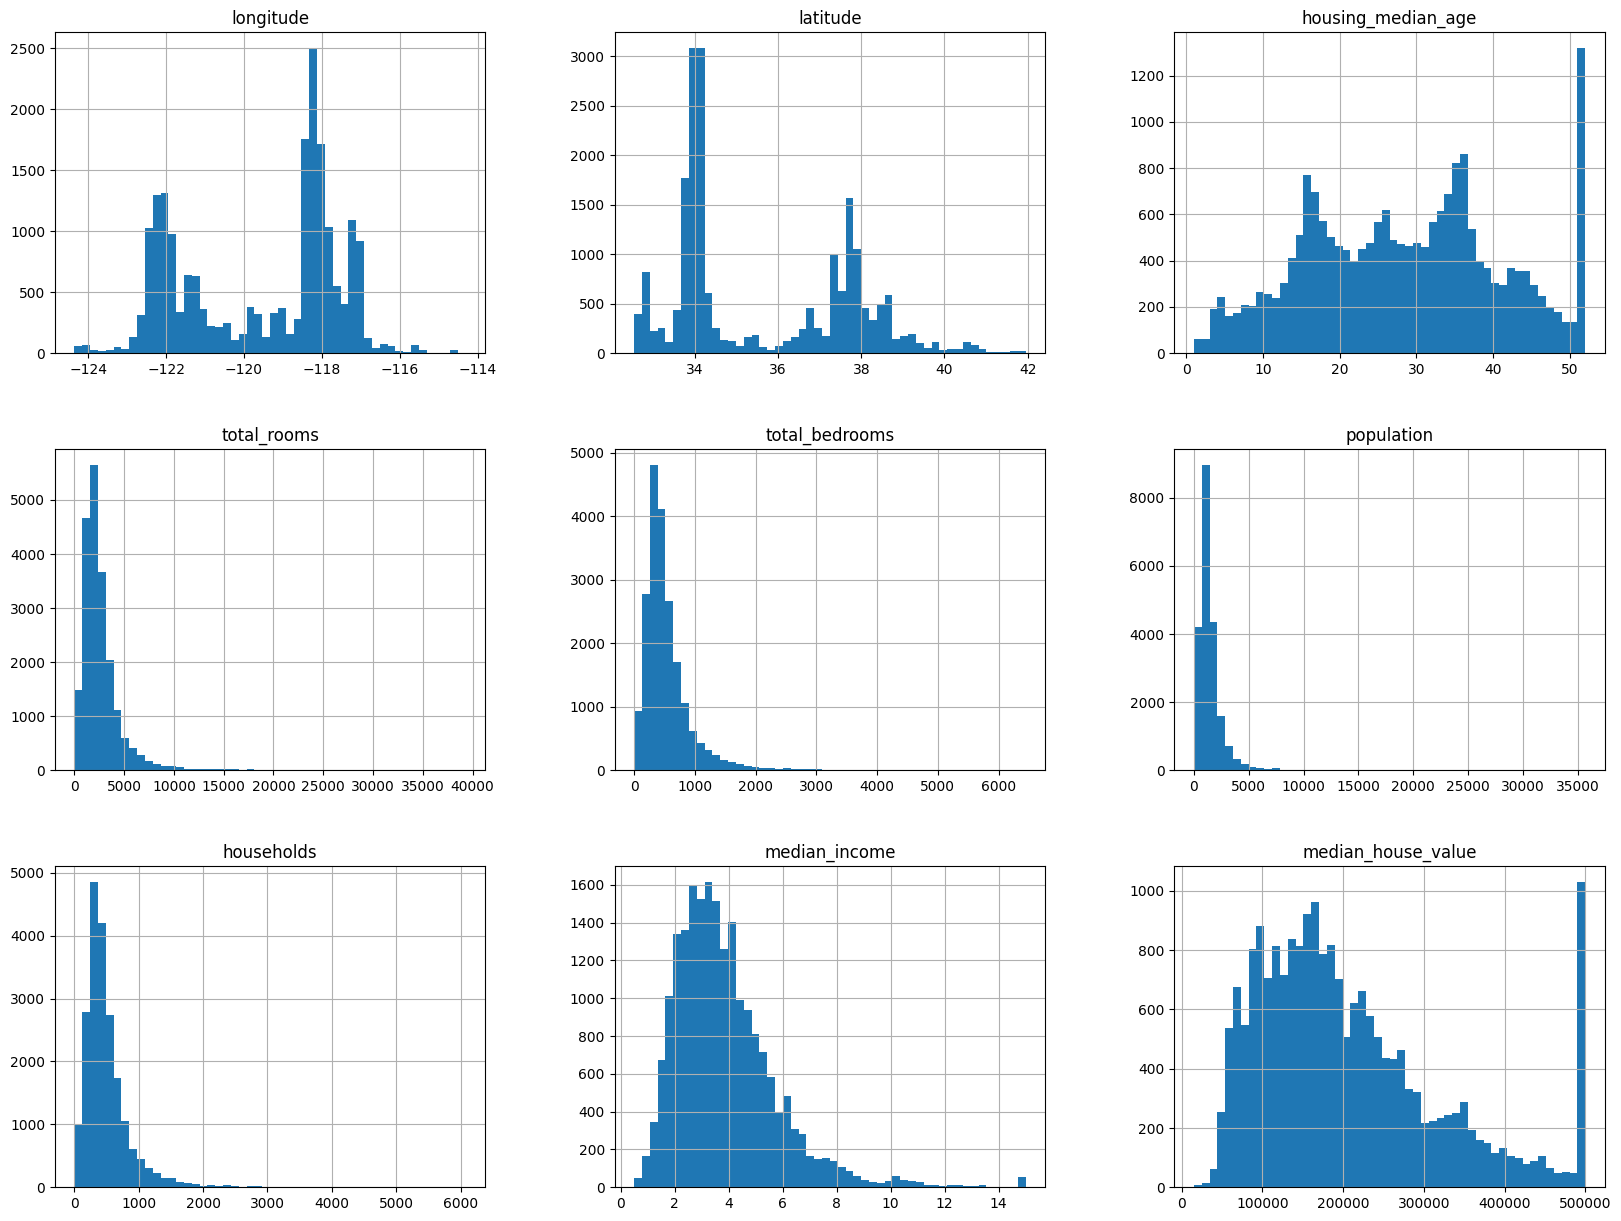

In [ ]:
df.hist(bins=50, figsize=(20,15)) # turli xulosalar olish mumkin. | Naodatiy qiymatlar 'housing_median_age'
plt.show()

**Train \ Test \ Validayion** qismlarga ajratish

In [ ]:
from sklearn.model_selection import train_test_split
train_set , test_set = train_test_split(df, test_size=0.2 , random_state=42)

Muvozanatli train / test ga ajratish | biror bir
ustun bo'yicha

In [ ]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1,2,3,4,5]) # guruxlash

from sklearn.model_selection import StratifiedShuffleSplit
stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# stratified_split.split funksiyasi indekslar qaytaradi
for train_index, test_index in stratified_split.split(df,df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

**Vizualziasiya**

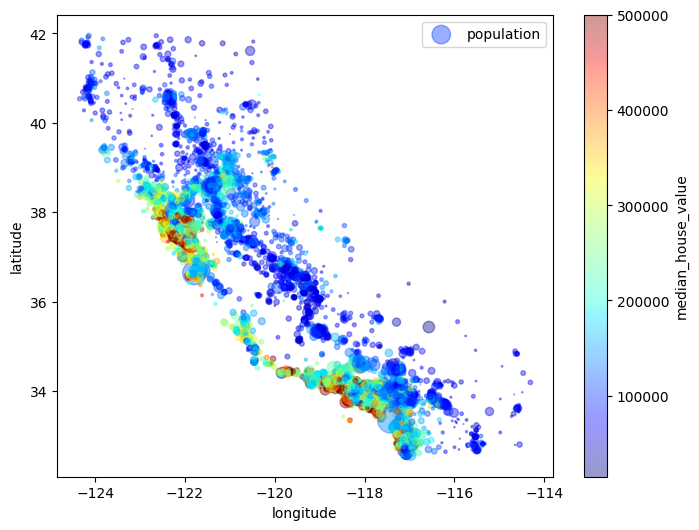

In [ ]:
housing = train_set.copy()

housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing['population']/100, # nuqta radiusi aholi soniga qarab o'zgaradi
    label="population",
    c="median_house_value", # nuqta rangi uyning narxiga qarab o'zgaradi
    cmap="jet", # ranglar. Ko'k - daromadi kam, qizil - daromadi ko'p
    colorbar=True,
    figsize=(8,6)
)
plt.show()

# Okeanga yaqin joylarda uylarning ham narxi qimmatroq
# Okeanga yaqin hududlarda aholi zichroq

**Korrelyasiya**

In [ ]:
housing_yield = housing['ocean_proximity']
housing.drop('ocean_proximity', axis=1 , inplace=True)

housing.corrwith(housing['median_house_value']).sort_values(ascending=False)

,0
median_house_value,1.000000
median_income,0.690647
total_rooms,0.133989
housing_median_age,0.103706
households,0.063714
total_bedrooms,0.047980
population,-0.026032
longitude,-0.046349
latitude,-0.142983


In [ ]:
housing.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924485,-0.101818,0.038676,0.063064,0.094276,0.049306,-0.017040,-0.046349
latitude,-0.924485,1.000000,0.005296,-0.029224,-0.059998,-0.102499,-0.064061,-0.076571,-0.142983
housing_median_age,-0.101818,0.005296,1.000000,-0.360922,-0.320624,-0.292283,-0.302796,-0.121711,0.103706
total_rooms,0.038676,-0.029224,-0.360922,1.000000,0.930489,0.857936,0.920482,0.198268,0.133989
total_bedrooms,0.063064,-0.059998,-0.320624,0.930489,1.000000,0.878932,0.980255,-0.009141,0.047980
population,0.094276,-0.102499,-0.292283,0.857936,0.878932,1.000000,0.907452,0.004122,-0.026032
households,0.049306,-0.064061,-0.302796,0.920482,0.980255,0.907452,1.000000,0.012776,0.063714
median_income,-0.017040,-0.076571,-0.121711,0.198268,-0.009141,0.004122,0.012776,1.000000,0.690647
median_house_value,-0.046349,-0.142983,0.103706,0.133989,0.047980,-0.026032,0.063714,0.690647,1.000000


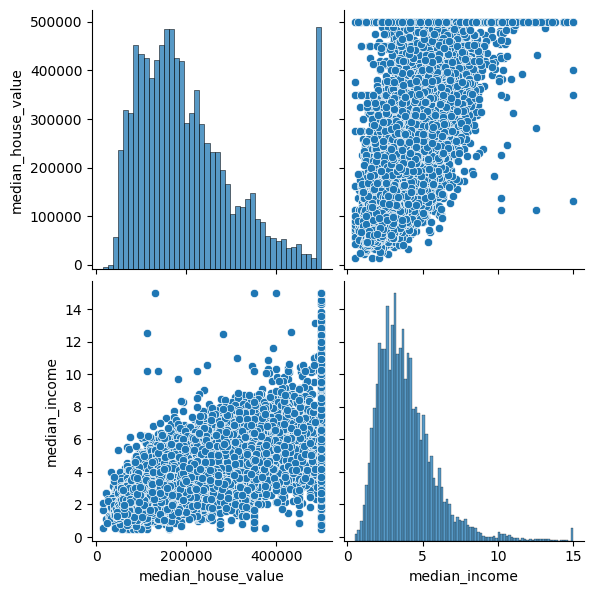

In [ ]:
cols = ['median_house_value','median_income']
sns.pairplot(housing[cols], height=3) # juft qilib chiqaradi
plt.show()

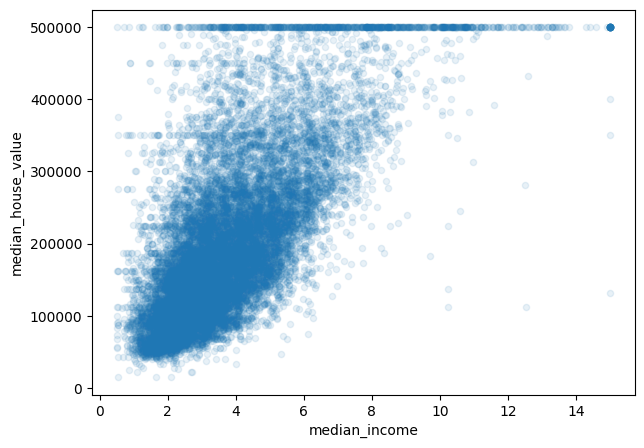

In [ ]:
housing.plot(kind='scatter', x="median_income", y="median_house_value", alpha=0.1, figsize=(7,5))
plt.show()

**Yangi parametrlar yaratish**

In [ ]:
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"] # yangi ustun

housing.corrwith(housing['median_house_value']).sort_values(ascending=False) # manfiy bog'liklik

,0
median_house_value,1.000000
median_income,0.690647
total_rooms,0.133989
housing_median_age,0.103706
households,0.063714
total_bedrooms,0.047980
population,-0.026032
longitude,-0.046349
latitude,-0.142983
bedrooms_per_room,-0.257419


### Ma'lumotlarni Machine Learning uchun tayyorlash

In [ ]:
URL = "https://github.com/ageron/handson-ml2/blob/master/datasets/housing/housing.csv?raw=true"
df = pd.read_csv(URL)

# train test setga ajratish
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

#javobni ajratib olish
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

**Tozalash**

In [ ]:
# 1-variant. Qatorlarni tashlab yuborish
housing.dropna(subset=['total_bedrooms']) # inplace=True

# 2-variant. Ustunni tashlab yuborish
housing.drop("total_bedrooms", axis=1)

# 3-variant. Median qiymat bilan to'ldirish
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median)

,total_bedrooms
14196,627.0
8267,787.0
17445,331.0
14265,367.0
2271,431.0
...,...
11284,201.0
11964,570.0
5390,569.0
860,597.0


**SimpleImputer**

In [ ]:
# SimpleImputer klassini chaqiramiz
from sklearn.impute import SimpleImputer
# SimpleImputer klassidan yangi obyekt yaratamiz va NaN qiymatlarni median qiymat bilan to'ldirishni ko'rsatamiz
imputer = SimpleImputer(strategy="median")

housing_num = housing.drop("ocean_proximity", axis=1) # matnli ustunlarni tashlab yuborish
imputer.fit(housing_num) # median qiymatlarni hisoblash
imputer.statistics_ # hisoblangan median qiymatlarni ko'rish
X = imputer.transform(housing_num) # hisoblangan median qiymatlar bilan to'ldirish

X = imputer.fit_transform(housing_num) # birdaniga bajarish

housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index) # np.array dan Df ga o'tkazish

**Matnli ustunlarni shakl almashtirish**

In [ ]:
housing_cat = housing[['ocean_proximity']]

from sklearn.preprocessing import OrdinalEncoder # 1- usul OrdinalEncoder -> Har bir matnni son bilan almashtirish.
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

**OneHotEncoder** - usuli yordamida har bir noyob qiymat alohida ustunga aylanadi va mos keluvchi ustunga 1, qolganlariga 0 qo'yiladi


In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

# pd.get_dummies(housing['ocean_proximity']) # OneHotEncoder bilan bir xil vazifani bajaradi va DF qaytaradi

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

**3.3 Transfomer**

**Estimator** - tahmin qiluvchi (baholovchi) funksiyalar. Bunday obyektlar .fit() metodiga ega bo'ladi, bu metod berilgan ma'lumotlardan qandaydur qiymatni hisoblaydi.

**Transformer** - ham tahmin qilib ham ma'lumotga ishlov beruvchi obyekt. Bunday obyektlar .fit_transform() metodiga ega bo'ladi, ya'ni avval qandaydur qiymatnbi hisoblaydi, keyin esa hisoblashni ma'lumotlarga qo'llaydi.

**Predictor** - bashorat qiluvchi obyektlar. Bunday obyektlar .predict() metodiga ega bo'ladi. Ular biz bergan ma'lumotlar asosida bashoratlar qaytaradi.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

# bizga kerak ustunlar indekslari
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self # bizni funksiyamiz faqat transformer. estimator emas
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room: # add_bedrooms_per_room ustuni ixtiyoriy bo'ladi
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

### 3.4 Standartizasiya va normalizasiya

In [ ]:
# MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
min_mix_scaler = MinMaxScaler()

min_mix_scaler.fit_transform(housing_num)

array([[0.72908367, 0.01702128, 0.62745098, ..., 0.06437961, 0.10228581,
        0.19032151],
       [0.61653386, 0.12978723, 0.94117647, ..., 0.0367443 , 0.12415721,
        0.22845202],
       [0.38545817, 0.22446809, 0.05882353, ..., 0.02556125, 0.05508962,
        0.25216204],
       ...,
       [0.59462151, 0.15744681, 0.68627451, ..., 0.04913254, 0.08649893,
        0.16789424],
       [0.23804781, 0.53510638, 0.2745098 , ..., 0.04972112, 0.09176122,
        0.35994676],
       [0.19223108, 0.55531915, 1.        , ..., 0.07332044, 0.20407828,
        0.14314285]])

In [ ]:
# Standard Scaler - standartlash

from sklearn.preprocessing import StandardScaler
standart_scaler = StandardScaler()
standart_scaler.fit_transform(housing_num)

array([[ 1.27258656, -1.3728112 ,  0.34849025, ...,  0.76827628,
         0.32290591, -0.326196  ],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.09890135,
         0.6720272 , -0.03584338],
       [-0.44760309, -0.46014647, -1.95271028, ..., -0.44981806,
        -0.43046109,  0.14470145],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ...,  0.28983345,
         0.07090859, -0.49697313],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.30830275,
         0.15490769,  0.96545045],
       [-1.41489815,  0.99543676,  1.85617335, ...,  1.04883375,
         1.94776365, -0.68544764]])

### **Pipeline - konveyer**

In [ ]:
import pandas as pd
import numpy as np
import sklearn # scikit-learn kutubxonasi

# Onlayn dataset joylashgan manzilini ko'rsatamiaz
URL = "https://github.com/ageron/handson-ml2/blob/master/datasets/housing/housing.csv?raw=true"
df = pd.read_csv(URL)

from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_set.drop("median_house_value", axis=1)
y = train_set["median_house_value"].copy()

X_num = housing.drop("ocean_proximity", axis=1)

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
# bizga kerak ustunlar indekslari
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self # bizni funksiyamiz faqat transformer. estimator emas
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room: # add_bedrooms_per_room ustuni ixtiyoriy bo'ladi
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

Pipeline yaratamiz

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# sonlar bilan ishlovchi pipeline

num_pipeline = Pipeline([
          ('imputer', SimpleImputer(strategy='median')),
          ('attribs_adder', CombinedAttributesAdder(add_bedrooms_per_room = True)),
          ('std_scaler', StandardScaler())
])

In [ ]:
from sklearn.compose import ColumnTransformer

num_attribs = list(X_num)
cat_attribs = ['ocean_proximity']

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

X_prepared = full_pipeline.fit_transform(X_train)

### **Linear Regression - Chiziqli regressiya**

In [ ]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

LR_model.fit(X_prepared, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-56276.06,-56638.23, 14122.3 ,...,112060.24,-24109.19,-15666.74]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.371e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,15
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[254. ,188.21,176.41,..., 13.5 , 2.23, 0. ]"


In [ ]:
# tasodifiy 5 ta qatorni ajratib olamiz
test_data = X_train.sample(5)
# yuqoridagi qatorlarga mos keluvchi narxlarni ajratib olamiz (biz aynan shu qiymatlarni bashorat qilishimiz kerak)
test_label = y.loc[test_data.index]
# pipelinedan o'tkazish
test_data_prepared = full_pipeline.transform(test_data)
# predict qilish
predicted_data = LR_model.predict(test_data_prepared)

pd.DataFrame({'Prognoz':predicted_data, 'Asl baxosi': test_label, "Farq": predicted_data - test_label })

,Prognoz,Asl baxosi,Farq
10073,97700.126044,117300.0,-19599.873956
15449,237695.716772,182600.0,55095.716772
11380,267902.873654,239200.0,28702.873654
19578,115844.920469,143600.0,-27755.079531
3646,188959.775213,183700.0,5259.775213


### 5-QADAM. **Modelni baholaymiz**

In [ ]:
X_test = test_set.drop('median_house_value', axis=1)
y_test = test_set['median_house_value'].copy()

X_test_prepared = full_pipeline.transform(X_test)

y_predicted = LR_model.predict(X_test_prepared)

In [ ]:
from sklearn.metrics import mean_squared_error
lin_mse = mean_squared_error(y_test, y_predicted)
# RMSE hisoblaymiz
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

72701.32600762135


**DecisionTree**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
Tree_model = DecisionTreeRegressor()
Tree_model.fit(X_prepared, y)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [ ]:
y_predicted = Tree_model.predict(X_test_prepared)

lin_mse = mean_squared_error(y_test, y_predicted)
# RMSE hisoblaymiz
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

72713.8776993286


**RandomForest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor()
RF_model.fit(X_prepared, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [ ]:
y_predicted = RF_model.predict(X_test_prepared)
lin_mse = mean_squared_error(y_test, y_predicted)
# RMSE hisoblaymiz
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

50319.187695119304


**Cross-Validation** usuli bilan baholash.

Cross validation uchun ma'lumotlarni train va testga bo'lish shart emas, buni sklearn o'zi qiladi.

In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"].copy()

X_prepared = full_pipeline.transform(X)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Std.dev:", scores.std())

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LR_model, X_prepared, y, scoring="neg_mean_squared_error", cv=10)
LR_rmse_scores = np.sqrt(-scores)

display_scores(LR_rmse_scores)

Scores: [84188.51219065 61197.24357613 86752.24346334 62289.14292385
 80540.40041898 68919.39949642 52503.82940087 90910.07884989
 77674.67507925 53941.60539478]
Mean: 71891.71307941683
Std.dev: 13249.525989444986


### **Modelni saqlash**

**pickle** yordamida saqlash

In [ ]:
import pickle

filename = 'RF_model.pkl' # faylga istalgan nom beramiz
with open(filename, 'wb') as file:
    pickle.dump(RF_model, file)

In [ ]:
with open(filename, 'rb') as file: # modelni o'qish
    model = pickle.load(file)

joblib yordamida saqlash

In [ ]:
import joblib

filename = 'RF_model.jbl' # faylga istalgan nom beramiz
joblib.dump(RF_model, filename)

filename = 'pipeline.jbl'
joblib.dump(full_pipeline, filename) # pipeline saqlash

['pipeline.jbl']

In [ ]:
model = joblib.load(filename) # modelni o'qish

# Supervised Learning

Supervised Learning (Nazorat ostida)

Regressiya (o'garuvchilar o'rtasida bog'liqlik)

• Bashorat (prognoz): iqlim, narx-navo, aholi soni, dollar kursi va hokazo

• Baholash: parametrlarga qarab uy, mashina, yerni baholash

Klassifikasiya

• Diagnostika

• Tasvirlarni ajratish

• Firibgarlikni aniqlash

• Mijozlarni saqlab qolish

Simple Regression -> Simple Linear Regression \ Simple non-Linear Regression

Multiple Regression -> Simple Multiple Regression \ Simple non-Multiple Regression

## **Regression**

### **Linear Regression**

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_LR.csv', index_col=0)

housing = df[df.district=='Чиланзарский']

X = housing['size'].to_numpy()
y = housing['price'].to_numpy()

Size va Price ustunlari orasidagi bog'liqlikni grafikga ko'ramiz

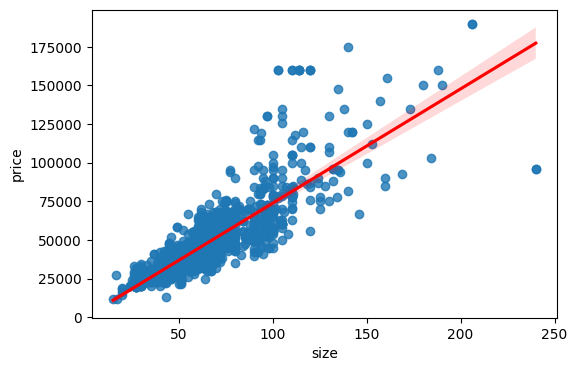

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(6,4))
sns.regplot(data=housing, x='size', y='price', line_kws={"color": "red"})
plt.show()

Linear regression formulasidagi theta1 va theta0 ni hisoblash

In [ ]:
import numpy as np

Xmean = np.mean(X)
ymean = np.mean(y)

theta1 = sum((X-Xmean)*(y-ymean))/sum((X-Xmean)**2)
print(f"{theta1=}")

theta0 = ymean - theta1*Xmean
print(f"{theta0=}")

theta1=np.float64(740.0264822713287)
theta0=np.float64(-195.94911352690542)


In [ ]:
# Saqlangan rasmni ochish
# from IPython.display import Image
# Image(url='https://i.imgur.com/zZoXZxI.png',height=200)

In [ ]:
x_test = housing.sample(10, random_state=42)['size'].to_numpy()
print(f"{x_test=}")
y_test = housing.sample(10, random_state=42)['price'].to_numpy()
print(f"{y_test=}")

y_predict = theta0 + theta1*x_test
print(f"{y_predict=}")

x_test=array([54., 42., 36., 60., 48., 68., 38., 65., 52., 44.])
y_test=array([37500., 26500., 25500., 39000., 32500., 34500., 22700., 47000.,
       37900., 36000.])
y_predict=array([39765.48092912, 30885.16314187, 26445.00424824, 44205.63982275,
       35325.3220355 , 50125.85168092, 27925.05721278, 47905.77223411,
       38285.42796458, 32365.21610641])


MSE (root mean square error), MAE (mean absolute error)

In [ ]:
# MAE
MAE = np.sum(np.absolute(y_predict-y_test))/len(y_test)
print(f"{MAE=}")

# RMSE
RMSE = np.sqrt(np.sum((y_predict-y_test)**2)/len(y_test))
print(f"{RMSE=}")

MAE=np.float64(4140.35031634715)
RMSE=np.float64(5882.051673173715)


### **Scikit-learn yordamida LR**

In [ ]:
# train / test

from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.10, random_state=42)

from sklearn import linear_model
LR_model = linear_model.LinearRegression()

x_train = np.asanyarray(train_set[['size']])
y_train = np.asanyarray(train_set[['price']])

# Modelni tarbiyalaymiz (train)
LR_model.fit(x_train, y_train)

#theta1 va theta0 koeefisentlarni ajratib olamiz
theta1 = LR_model.coef_[0][0]
theta0 = LR_model.intercept_[0]
print (f'{theta1=}')
print (f'{theta0=}')

theta1=np.float64(732.7784051414766)
theta0=np.float64(106.31843170110369)


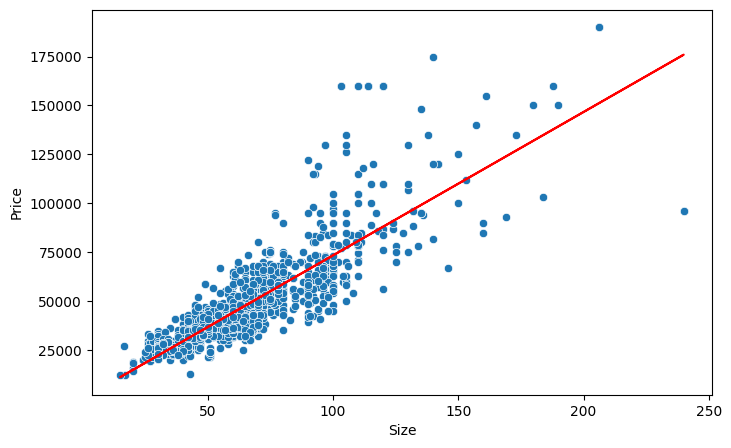

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=housing, x='size', y='price')
plt.plot(x_train, theta1*x_train + theta0, '-r')
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

Modelni baholash

In [ ]:
x_test = np.asanyarray(test_set[['size']])
y_test = np.asanyarray(test_set[['price']])

y_predict = LR_model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=7269.709648262382
RMSE=np.float64(12734.803748258666)


### **Multiple Linear Regression**

Ishlatilishi:

Qaysi parametrlar muhimligini aniqlash

Parametlar o'zgarishining tasirini aniqlash uchun

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_LR.csv', index_col=0)

housing = df[df.district=='Чиланзарский']
housing.head()

# train/test
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.10, random_state=42)

from sklearn import linear_model
MLR_model = linear_model.LinearRegression()

# x_train = np.asanyarray(train_set[['rooms','size','level','max_levels']])
x_train = np.asanyarray(train_set[['size','max_levels']]) # bir nechta ustun olinsa bu Multiple LR
y_train = np.asanyarray(train_set[['price']])
MLR_model.fit (x_train, y_train)

# Koeffisientlar (theta1, theta2, ...)
print('Coefficients: ', MLR_model.coef_)
print('theta0:', MLR_model.intercept_)

Coefficients:  [[ 747.04795007 -393.4032521 ]]
theta0: [1341.57534414]


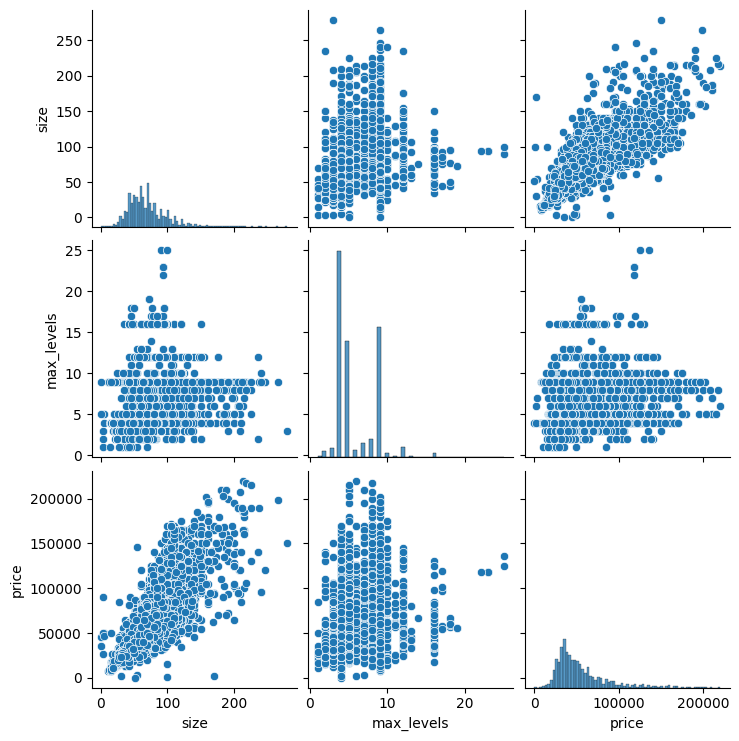

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.pairplot(df[['size','max_levels','price']]) # bog'liqlikni ko'rish uchun grafik
plt.show()

In [ ]:
# x_test = np.asanyarray(test_set[['rooms','size','level','max_levels']])
x_test = np.asanyarray(test_set[['size','max_levels']])
y_test = np.asanyarray(test_set[['price']])
y_predict = MLR_model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=7193.9223780657785
RMSE=np.float64(12635.660248895361)


### **Polynomial Regression**

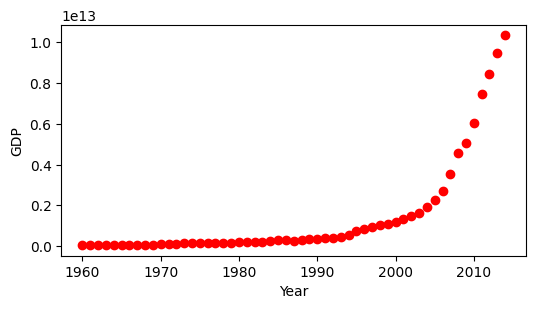

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/china_gdp.csv"

df = pd.read_csv(url)

plt.figure(figsize=(6,3))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, 'ro')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

In [ ]:
# Normalisatsiya

X = np.asanyarray(df[['Year']]/df.Year.max())
y = np.asanyarray(df[['Value']]/df.Value.max())

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_features = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly_features.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

yhat = model.predict(X_poly)

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(X, y, 'ro', label='data')
plt.plot(X,yhat, linewidth=4.0, label='fit')
plt.show()

In [ ]:
print("MAE:", mean_absolute_error(yhat,y))

MAE: 0.03787485630774937


curve_fit yordamida o'zimiz yozgan funksiyalar asosida model qurishimiz mumkin.

In [ ]:
# Saqlangan rasmni ochish
from IPython.display import Image
Image(url='https://miro.medium.com/v2/resize:fit:1046/1*l59BUnPwWHMf1H-GNxgZHQ.png',height=100)

# Sigmoid/ Logistic Regression formula

In [ ]:
x_data, y_data = (df["Year"].values, df["Value"].values)
xdata =x_data/max(x_data)
ydata =y_data/max(y_data)

def sigmoid(x, Beta_1, Beta_2):
     y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
     return y

from scipy.optimize import curve_fit

beta, pcov = curve_fit(sigmoid, xdata, ydata)
print(f"beta1={beta[0]}\nbeta2={beta[1]}")

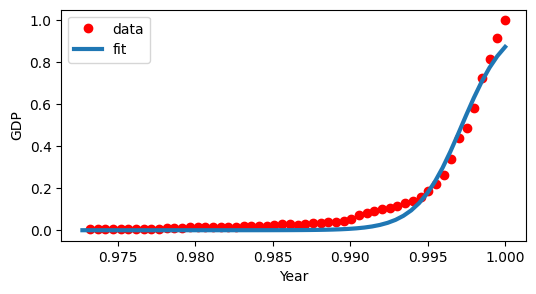

In [ ]:
x = np.linspace(1960, 2015, 55)
x = x/max(x)
plt.figure(figsize=(6,3))
yhat = sigmoid(x, *beta)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x,yhat, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

In [ ]:
print("MAE:", mean_absolute_error(yhat,ydata))

MAE: 0.030498418817641204


**Non-Linear Regression formulas**

In [ ]:
Image(url='https://i.ytimg.com/vi/rb_IXh6aBK0/hqdefault.jpg')

### Overfitting / Underfitting

Underfitting -> Model juda sodda . Train setda ham test setda ham katta xatolik.

High bias (gumon)

Overfitting --> Model juda murakkab . Train setga moslashib qolgan. -> Train setda aniqlik baland (xato kam) , Test setda aniqlik juda ham past (xato ko'p)

High variance (farq)

Yaxshi model-> Train va Test setlarda birdek katta aniqlik

Low bias , low variance

Underfitting -> Modelni murakkablashtirish kerak.

1. Ko'proq parametrlar qo'shish
2. Polynomial darajani oshirish
3. Ko'proq qavatlar qo'shish(Deep learning)

Overfitting -> Modelni soddalashtirish kerak

1. Parametlarni kamaytirish
2. Algorithm ni o'zgartirish
3. Polynomial darajani kamaytirish
3. Ko'proq malumot yig'ish

In [ ]:
Image(url="https://miro.medium.com/v2/resize:fit:1125/1*_7OPgojau8hkiPUiHoGK_w.png", height=200)

## **Classification**

**Classification** - Nomalum elementlarni kategoriyalarga (class) larga ajratish.

Ishlatilishi:

1. MIjozlarni kategoriyalarga ajratish
2. MIjoz qaytish yoki qaytmasligi (Customer churn)
3. Biror reklama mijozga to'g'ri kelish kelmasligi(targeted marketing)
4. Objectlarni aniqlsh , ajratish
5. Yuzni tanish(Face Id)
6. Qo'l yozma va Nutqni tushunish
7. Tavsiya tizimlari

In [ ]:
from IPython.display import Image
# classification algorithms
Image(url='https://miro.medium.com/v2/resize:fit:1200/1*R6Rbcks-pGO0SkhCINrP0g.png', height=600)

**Logistic Regression**

Afzalligi -- Ehtimollikka asoslangan, har bir parameter muhimligini ham ko'rsatadi
Kamchiligi --Ustunlar o'rtasida logistic bog'liqlikni talab qiladi

**K-NN**

Afzalligi -- Sodda, tez va samarali

Kamchiligi -- K-qiymatini to'g'ri topish kerak

**Support Vector Machine (SVM)**

Afzalligi -- Samarali, noodatiy qiymatlarga sezgir emas, overfitting oldini oladi

Kamchiligi -- Ko'p ustunli (parametrli) datasetlarga to'g'ri kelmaydi. Chiziqli bo'lmagan muammolarga tushmaydi

**Kernel SVM**

Afzalligi-- Chizigli bo'Imagan muammolar uchun

Kamchiligi-- Ko'p ustunli (parametrli) datasetlarga to 'g'ri kelmaydi.

Decision Tree

Afzalligi -- Tushunishga oson, parametrlarga ishlov berish talab qilinmaydi, chiziqli va chiziqli bo'lmagan muammolarga birdek tushadi

Kamchiligi -- Kichik datasetlarda overfitting yuzaga keladi.

Random Forest

Afzalligi -- Aniqligi baland. Turli muammolarda yaxshi natija.

Kamchiligi -- Tushunishga qiyin, tarkibidagi daraxtlar sonini aniqlash kerak, overfittinga moyil

In [ ]:
# classification algorithms
Image(url='https://miro.medium.com/v2/resize:fit:1080/1*p71ftGT0uRExSsmqCJ6-YA.jpeg',height=600)

### **KNN** - K-nearest neighbor-> k ta eng yaqin qo'shnilar

klearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

sklearn.neighbors.KNeighborsClassifier - bu sklearn kutubxonasi orqali taklif etilgan K-nearest neighbors (KNN) klassifikatori. U haqiqiy qiymatlar (sinfikatsiya maqsadida) uchun eng yaqin qo'shilgan n ta namunalarning kuchli "ko'rsatkichlari"ni hisoblash uchun ishlatiladi. Bu klassifikator yaxshi qilib ko'rsatilgan.

leaf_size: KD-derevo yoki ball agaci algoritmlarining barglari (integer, default=30). Ushbu parametr, izlash jarayonini tezlashtirish uchun belgilangan barglar sonini belgilaydi.

p: Masofa miqdori (integer, default=2). Ushbu parametr, masofa metrikasini aniqlaydi. Agar p=1 bo'lsa, masofa metrikasi manhattan masofasi (l1), agar p=2 bo'lsa, masofa metrikasi euclidean masofasi (l2) hisoblanadi.

metric: Masofa metrikasi (string, default='minkowski'). Ushbu parametr, qo'shilganlar orasidagi masofani hisoblash uchun foydalaniladigan metrikani belgilaydi.


In [ ]:
import pandas as pd
import numpy as np

url="https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/breast-cancer.csv"
df = pd.read_csv(url)

# Harfli qiymatlarni songa o'zgartirish uchun sklearn tarkibidagi LabelEncoder dan yoki pandas dagi .replace() metodidan foydalanish mumkin.

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

df['diagnosis'] = labelencoder.fit_transform(df['diagnosis'].values)
# df['diagnosis'] = df['diagnosis'].replace("M",1)
# df['diagnosis'] = df['diagnosis'].replace("B",0)
df['diagnosis'].value_counts()

In [ ]:
# df.drop(columns=['id'], inplace=True)

corr_matrix = df.corr().abs().sort_values(by='diagnosis', ascending=False).head(8)
corr_matrix.style.background_gradient(cmap='Blues')

In [ ]:
df.corrwith(df['diagnosis']).abs().sort_values(ascending=False).head(10)

In [ ]:
# ML ga tayyorlaymiz

X = df.drop('diagnosis', axis=1).values
y = df['diagnosis']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Ml

# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=12)

# k-NN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5) # k-ni qiymati

knn.fit(X_train, y_train)

In [ ]:
y_predict = knn.predict(X_test)

### **Classificator modelini baholash.**

**Jaccard index** -> ikki to'plam orasidagi bog'liqlikni ko'rsatadi.*italicised text*

In [ ]:
Image(url='https://media.geeksforgeeks.org/wp-content/uploads/20230811131746/How-to-Calculate-Jaccard-Similarity-in-Python.png', height=100)

Confusion matrix (Precision, Recall)

In [ ]:
Image(url='https://www.researchgate.net/publication/370070277/figure/fig3/AS:11431281149637241@1681824354931/Confusion-matrix-and-performance-metrics-formula.png', height=300)

In [ ]:
#Baholash

from sklearn.metrics import jaccard_score

jaccard_score(y_test, y_predict)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

Precision, recall, F1

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)
accuracy = accuracy_score(y_test, y_predict)
print(f"{precision=}\n{recall=}\n{f1=}\n{accuracy=}")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

Cross-validation yordamida tekshiramiz

In [ ]:
# Cross validation
from sklearn.model_selection import cross_val_predict
predict = cross_val_predict(estimator = knn, X = X, y = y, cv = 5)

# Modelni baholash
from sklearn.metrics import classification_report
print("Classification Report: \n",classification_report(y, predict))

Eng yaxshi k ni topish

In [ ]:
f1 = []
for k in range(1,25):
    knn = KNeighborsClassifier(n_neighbors=k) # k-ni qiymati
    knn.fit(X_train, y_train)
    y_predict = knn.predict(X_test)
    f1.append(f1_score(y_test, y_predict))

plt.figure(figsize=(6,3))
plt.plot(range(1,25),f1)
plt.xticks(range(1,25))
plt.grid()
plt.show()

Grid Search yordamida

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 25)}

knn_gscv = GridSearchCV(knn, param_grid, cv=5)

knn_gscv.fit(X, y)

In [ ]:
knn_gscv.cv_results_['rank_test_score']

In [ ]:
knn_gscv.best_params_

In [ ]:
knn_gscv.best_score_

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel("k")
plt.ylabel("Xatolik reytingi")
plt.grid()
plt.show()

### **Decision Tree**

1. Datasetdagi biror ustunni tanlaymiz
2. Malumotlarni bo'lishda ustun muhimligini aniqlaymiz
3. Eng yaxshi ustun bo'yicha malumotlarni bo'lamiz
4. Qadamlarni takrorlash

sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)

min_impurity_decrease' - natija qanchalik "toza" bo'lishini belgilaydi. Standart qiymati 0

max_depth - shajara qavatlari soni

min_samples_leaf - leaf node (yakuniy, barg tugun) hosil qilish uchun eng kam elementlar soni

In [ ]:
# Entropia ni hisoblash formulasi . Entropia qancha kichik bo'lsa shuncha yaxshi
Image(url='https://www.researchgate.net/publication/372233393/figure/fig9/AS:11431281173487072@1688949412713/Figura-1-Formula-de-la-entropia-de-la-Teoria-Matematica-de-la-Informacion-de-Shannon.png')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn import tree
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv"
df = pd.read_csv(url)

In [ ]:
# Matnli ustunlarga ishlov
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'].values)
df['BP'] = encoder.fit_transform(df['BP'].values)
df['Cholesterol'] = encoder.fit_transform(df['Cholesterol'].values)

X = df[['Age','Sex','BP','Cholesterol','Na_to_K']].values

y = df['Drug'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=20)

# Model

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Baholash

y_predict = tree_model.predict(X_test)

print(classification_report(y_test, y_predict))

print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, y_predict))

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, cmap="Greens")
plt.show()

In [ ]:
# Cross Validation

predict = cross_val_predict(estimator = tree_model, X = X, y = y, cv = 5)
print("Classification Report: \n",classification_report(y, predict))

Decision Tree chizamiz

In [ ]:
cols = df.drop('Drug', axis=1).columns
classes = df['Drug'].unique()

plt.figure(figsize=(10,8))
tree.plot_tree(tree_model, feature_names=cols, class_names=classes,filled=True)
plt.show()

### **Hyperparameters**

Har bir model o'ziga xos **giperparametrlar** bilan keladi, biz bu parametrlarni sozlash orqali model aniqligini yoki tezligini oshirishimiz mumkin.

k-NN uchun bu k ya'ni qo'shnilar soni edi. Decision Treen da esa bir nechta giperparametrlar mavjud.

Barcha parametrlarni ushbu link orqali ko'rishingiz mumkin: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

**`min_impurity_decrease'** - natija qanchalik "toza" bo'lishini belgilaydi. **Standart qiymati 0**

In [ ]:
tree_model = DecisionTreeClassifier(min_impurity_decrease=0.01) # Qanchagacha aniqlikda hisoblash
tree_model.fit(X_train, y_train)
y_predict = tree_model.predict(X_test)
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, y_predict))

plt.figure(figsize=(10,8))
tree.plot_tree(tree_model, feature_names=cols, class_names=classes, filled=True)
plt.show()

max_depth - shajara qavatlari soni

In [ ]:
tree_model = DecisionTreeClassifier(min_impurity_decrease=0.0, max_depth=3)
tree_model.fit(X_train, y_train)
y_predict = tree_model.predict(X_test)
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, y_predict))

plt.figure(figsize=(10,8))
tree.plot_tree(tree_model, feature_names=cols, class_names=classes, filled=True)
plt.show()

min_samples_leaf - leaf node (yakuniy, barg tugun) hosil qilish uchun eng kam elementlar soni

In [ ]:
tree_model = DecisionTreeClassifier(min_samples_leaf=5, max_depth=3)
tree_model.fit(X_train, y_train)
y_predict = tree_model.predict(X_test)
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, y_predict))

plt.figure(figsize=(10,8))
tree.plot_tree(tree_model, feature_names=cols, class_names=classes, filled=True)
plt.show()

### **Random Forest**

sklearn.ensemble.RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)

Asosiy parametrlar:

n_estimators: Qaror derevalar soni (integer, default=100). Ushbu parametr, qancha ko'plab qaror derevalarini (decision trees) ishlatish kerakligini belgilaydi.

criterion: Qaror derevasi (decision tree) qurilishi (string, default='gini'). Ushbu parametr, qaror derevasi uchun qurilishi ni belgilaydi:

'gini': Gini impurity ni o'rnating.\
'entropy': Entropiya ni o'rnating.

max_depth: Qaror derevalarining maksimal qat'iyati (integer or None, default=None). Ushbu parametr, qaror derevalarining maksimal qat'iyatini chegaralaydi.

min_samples_split: Qaror derevasi uchun eng kichik namunalarning bo'linishi kerak bo'lgan minimal namunalar soni (integer or float, default=2). Ushbu parametr, qaror derevasi uchun namunalar sonini belgilaydi.

min_samples_leaf: Har bir qaror derevasi uchun eng kam namunalarni quyidagi qurilishni aniqlash (integer or float, default=1). Ushbu parametr, qaror derevalarining har bir qat'iyatida eng kam namunalar sonini belgilaydi.

max_features: Har bir qaror derevasi uchun qo'llanilishi mumkin bo'lgan maksimal xususiyatlar soni (int, float, string or None, default='sqrt'). Ushbu parametr, qaror derevasi uchun qo'llanilishi mumkin bo'lgan maksimal xususiyatlar sonini belgilaydi.

**n_estimators** - o'rmondagi daraxtlar soni.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=20)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, y_pred))



Logistic Regression -> Classification model -> asosan Binary Classification uchun ishlatladi.

# **Unsupervised Learning**

**Unsupervised Learning** (Nazoratsiz)

Ishlatilishi:

**Klasterlash** (guruhlash)

• Tavsiya tizimlari

• Yo'naltirilgan marketing

• Mijozlarni guruhlash

**Ma'lumot o'chamini kamaytirish (5D→2D)**

• Katta ma'lumotlarni vizualizasiya qilish

• Paramterlarni jamlash

• Ma'lumotlarni siqish

**Qonuniyatlarni topish**

**Anomal (noodatiy) qiymatlarni aniqlash**

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

n_samples - nuqtalar soni

centers - klasterlar markazi (sentroid) koordinatalari

-cluster_std - markazdan standart og'ish

In [ ]:
np.random.seed(0)
centroids = [[3,3], [-3, -2], [2, -3], [0, 0]]
X, y = make_blobs(n_samples=5000, centers=centroids, cluster_std=0.8)

plt.scatter(X[:, 0], X[:, 1], marker='.')
plt.show()

### **k-means algoritmi**

KMeans funksiyasi quyidagi parametrlarni qabul qiladi:

init - sentrodilarni tanlash usuli (k-means++ yoki random)

n_clusters - klastertlar soni

n_init - algoritmni necha marta ishga tushirish (turli sentroidlar bilan qayta-qayta ishga tushirib, modelni qurishni boshlash uchun eng yaxshi sentroidlar tanlanadi)

k-means algoritmi

- Har bir klaster uchun tasodifiy sentroidlarni tanlash
◦
- Har bir nuqtadan sentroidgacha masofani o'Ichash
◦
- Har bir nuqtani eng yaqin sentroidga biriktirish
◦
- Sentroidlarni siljitish
◦
- 2-4 qadamlarni setroidlar siljishi to'tagunga qadar takrorlash

In [ ]:
k_means = KMeans(init = 'k-means++', n_clusters = 3, n_init = 15)

k_means.fit(X)

In [ ]:
# Saqlangan rasmni ochish
from IPython.display import Image
Image(url='https://www.researchgate.net/profile/Mahesh-Sarathchandra/publication/344888655/figure/fig1/AS:950914114408448@1603727000307/k-means-objective-function.ppm',height=200)

# Xatolikni minimallashtirish formulasi

In [ ]:
Image(url='https://miro.medium.com/v2/resize:fit:850/1*9ihLnBj-RV2h4e-VEimEbw.png', height=300)

#Elbow method -> Klasterlar soni k ni qanday tanlaymiz?

In [ ]:
k_means.labels_   #Klaster raqamini ko'rish

k_means.cluster_centers_  # Klaster markazlarini ko'rish

print(centroids)

print(np.round(k_means.cluster_centers_))

In [ ]:
fig = plt.figure(figsize=(8, 8))
# Har bir klaster uchun alohida rang
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means.labels_))))
ax = fig.add_subplot(1, 1, 1)

for k, col in zip(range(len([[3,3], [-3, -2], [2, -3], [0, 0]])), colors):

    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means.labels_ == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means.cluster_centers_[k]

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()

In [ ]:
url="https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/customer_segmentation.csv"
df = pd.read_csv(url)
df.head()

In [ ]:
df.info()

In [ ]:
df.drop('Address', axis=1, inplace=True)
df.head()

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.values[:,1:]
X = np.nan_to_num(X)
norm_data = StandardScaler().fit_transform(X)
norm_data

In [ ]:
k = 3
k_means = KMeans(n_clusters = k) # init va n_init standart qiymatlarni qabul qiladi, biz faqat klasterlar sonini ko'rsatdik.
k_means.fit(norm_data)
print(k_means.labels_)

In [ ]:
df['cluster'] = k_means.labels_
df.head()

In [ ]:
df.groupby('cluster').mean()

In [ ]:
area = np.pi * ( X[:, 1])**2
plt.scatter(X[:, 0], X[:, 3], s=area, c=k_means.labels_.astype(float), alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)

plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(1, figsize=(8, 6))
plt.clf()
ax = Axes3D(fig, rect=[0, 0, .95, 1], elev=48, azim=120)

plt.cla()
# plt.ylabel('Age', fontsize=18)
# plt.xlabel('Income', fontsize=16)
# plt.zlabel('Education', fontsize=16)
ax.set_xlabel('Years Employed')
ax.set_ylabel('Age')
ax.set_zlabel('Income')

ax.scatter(X[:, 2], X[:, 0], X[:, 3], c= k_means.labels_.astype(float))

Afzalligi

Klasterlar sonini belgilash talab qilinmaydi

Oson

Dendogram yordamida ma'lumotni tahlil gilish oson

Kamchiliklari:

Avalgi qadamni bekor qilib bo'lmaydi

Uzoq vaqt oladi

Dendogramdan kerakli klasterlar sonini ajratib olish murakkab

Ierarxik (hierarchical) algoritm

- lerarxik klasterlash algoritmi klasterlar ierarxiyasini quradi, bunda har bir tugun klaster bo'ladi va o'zidan keying tugun klasterlarini o'z ichiga oladi.

In [ ]:
Image(url='https://miro.medium.com/v2/resize:fit:1400/0*afzanWwrDq9vd2g-',height=300)

**Iyerarxik klasterlash qadamlari**

1. Har bir nugtani alohida klaster deb ajratib olamiz

2. Yaqinlik matrisasini quramiz

3. Bir dona klaster qolgunga qadar quidagi gadamlarni takrorlaymiz

     - Eng yagin ikki klasterni birlashtirish

     - Yaginlik matrisasini yangilash

**Klasterlar o'rtasidagi masofa**

- Single-linkage Clustering ->Klasterlar o'rtasidagi minimum masofa

- Complete-linkage Clustering -> Klasterlar o'rtasidagi maksimum masofa

- Average Linkage clustering -> Klasterlar o'rtasidagi o'rta masofa

- Centroid Linkage clustering -> Klaster markazlari orasidagi masofa

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/cars_clus.csv"
df = pd.read_csv(url)
df.head()

In [ ]:
df[[ 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']] = df[['sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']].apply(pd.to_numeric, errors='coerce') # raqamli ustunga aylantirish
df = df.dropna()
df = df.reset_index(drop=True) # indexni tashlab yuborish
df.head(5)

In [ ]:
# Klasterlash uchun ustunlarni tanlab olamiz.
featureset = df[['engine_s',  'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg']]

# Normalizasiya
from sklearn.preprocessing import MinMaxScaler
x = featureset.values #numpy array
min_max_scaler = MinMaxScaler()
feature_mtx = min_max_scaler.fit_transform(x)
feature_mtx[0:5]

Irarxik klasterlash uchun Scipy paketidan foydalanmiz.

Boshlanishiga distance matrix D (masofalar matrisasini) quramiz:

In [ ]:
import scipy
from scipy import ndimage
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix

leng = feature_mtx.shape[0]
D = np.zeros([leng,leng])
for i in range(leng):
    for j in range(leng):
        D[i,j] = scipy.spatial.distance.euclidean(feature_mtx[i], feature_mtx[j])
D

In [ ]:
# training
Z = hierarchy.linkage(D)

In [ ]:
# Dendogram

fig = plt.figure(figsize=(18,50))
def llf(id):
    return '[%s %s %s]' % (df['manufact'][id], df['model'][id], int(float(df['type'][id])) )

dendro = hierarchy.dendrogram(Z,  leaf_label_func=llf, leaf_rotation=0, leaf_font_size =12, orientation = 'right')

In [ ]:
from scipy.cluster.hierarchy import fcluster
k = 5 # 5 ta klaster
clusters = fcluster(Z, k, criterion='maxclust')
clusters

In [ ]:
# scikit yordamida klasterlash

from sklearn import manifold, datasets
from sklearn.cluster import AgglomerativeClustering

agglom = AgglomerativeClustering(n_clusters = 6, linkage = 'complete')
agglom.fit(D)

agglom.labels_

**k-means**

Tez, katta datasetlarda qo'llash mumkin

Klasterlar sonini oldindan ko'rsatish kerak

Faqatgina bitta variant beradi

Sentroidlarni tasodifiy tanlash evaziga har doim har xil
natija qaytadi

**lyerarxik algoritm**

Sekin, katta datasetlarda hisob-kitob uzoq vaqt oladi

Klasterlar soni talab qilinmaydi

Dendogramdan klasterlar sonini o'zgartirishimiz
mumkin

Har doim bir xil klasterlarni qaytaradi

 **DBSCAN** --> Densitiy-Based Spatial Clustering of Application with Noise

 • Eng ko'p qo'llaniladigan algoritm

• Asosiy g'oya: Biror nuqta klasterga tegishli bo'lsa bu
nuqta atrofida klasterga tegishli boshqa ko'plab nuqtalar
bo'lishi kerak

**• Asosiy parametrlari:**

• R (qo'shni nuqtalargacha radius) - berilgan radisudagi
qo'shnilar soni

• M (minimum qo'shnilar soni) - klaster shakllantirish
uchun minimum nuqtalar soni

**Avzalliklari:**

◦	Istalgan shakldagi klasterlarni aniqlaydi

◦	Shovginga sezgir va noodatiy qiymatlarni ajrata oladi

◦	Klasterlar sonini ko'rsatish talab qilinmaydi

k-means noodatiy giymatlarni ham klasterga biriktiradi

DBSCAN Zichlik asosidagi algoritmlar zich joylashgan hududlarni birlashtirib, noodatiy qiymatlarni ajratib beradi

In [ ]:
Image(url='https://miro.medium.com/v2/resize:fit:1358/1*KqWII7sFp1JL0EXwJGpqFw.png',height=300)

Nuqtalar 3 turli bo'lishi mumkin:
- Core (markaz)
- Border (chegara)
- Outlier (noodatiy)

DBSCAN maqsadi:

• har bir nuqtani tahlil qilish va yuqoridagi turlardan biriga
ajratish

• Nuqtalarni klasterlarga ajratish

**Klaster:** Barcha go'shni Markaz nuqtalar va ularga tegishli Chegara nuqtalar.

**Core point:**

  R radiusda kamida M nuqta bilan tutashgan nuqta.

**Border point:**

  M dan kam nuqtalar bilan tutash yoki Core point bilan qo'shni.

**Outlier point:**

  Markaz yoki Chegara bo’magan nuqta.

# **Scikit_learn**

In [ ]:
from sklearn.model_selection import train_test_split

# sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

### Imputers

sklearn.impute

class sklearn.impute.SimpleImputer(*, missing_values=nan, strategy='mean', fill_value=None, copy=True, add_indicator=False, keep_empty_features=False)

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer

# SimpleImputer klassidan yangi obyekt yaratamiz va NaN qiymatlarni median qiymat bilan to'ldirishni ko'rsatamiz
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num) # median qiymatlarni hisoblash
imputer.statistics_ # hisoblangan median qiymatlarni ko'rish

X = imputer.transform(housing_num) # NaN qiymatlarni median qiymat bilan to'ldirish
X = imputer.fit_transform(housing_num)

housing = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index) # np.array dan Df ga o'tkazish

class sklearn.impute.KNNImputer(*, missing_values=nan, n_neighbors=5, weights='uniform', metric='nan_euclidean', copy=True, add_indicator=False, keep_empty_features=False)

n_neighbors: Necha qo'shni (neighbors) ko'rib chiqilishini belgilaydi. Default qiymat 5.

weights: Qo'shnilarning qiymatlari qanday og'irlik bilan hisoblanishini belgilaydi. "uniform" qiymati barcha qo'shnilarni teng og'irlikda hisoblaydi, "distance" esa masofaga qarab og'irlik beradi.

In [ ]:
# Misol ma'lumotlar to'plami
data = np.array([[1, 2, np.nan],
                 [3, np.nan, 5],
                 [np.nan, 4, 6]])

# Imputer yaratish
imputer = KNNImputer(n_neighbors=2)

# Yo'qolgan qiymatlarni to'ldirish
imputed_data = imputer.fit_transform(data)

print(imputed_data)

### Scalers

sklearn.preprocessing

StandardScaler

class sklearn.preprocessing.StandardScaler(*, copy=True, with_mean=True, with_std=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

data = np.array([[1, 2], [3, 4], [5, 6]])

# StandardScaler ob'ektini yaratish
scaler = StandardScaler()

# Ma'lumotlarni o'zgartirish
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Standartlashtirilgan ma'lumotlar:")
print(scaled_data)

MinMaxScaler

class sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Misol ma'lumotlar
data = np.array([[1, 2], [3, 4], [5, 6]])

# MinMaxScaler ob'ektini yaratish
scaler = MinMaxScaler(feature_range=(0, 1))

# Ma'lumotlarni shkalalash
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Shkalalangan ma'lumotlar:")
print(scaled_data)

RobustScaler

class sklearn.preprocessing.RobustScaler(*, with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), copy=True, unit_variance=False)

RobustScaler - bu Scikit-learn kutubxonasidagi funksiya bo'lib, sonli ma'lumotlarni standartlashtirish uchun ishlatiladi, lekin u outlier (juda katta yoki juda kichik qiymatlar) larni inobatga olgan holda ishlaydi.

outlierlar oddiy shkalalash usullariga (masalan, StandardScaler yoki MinMaxScaler) ta'sir qilishi mumkin.

In [ ]:
from sklearn.preprocessing import RobustScaler

# Misol ma'lumotlar
data = np.array([[1, 2], [3, 4], [5, 100]])

# RobustScaler ob'ektini yaratish
scaler = RobustScaler()

# Ma'lumotlarni shkalalash
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Shkalalangan ma'lumotlar:")
print(scaled_data)

MaxAbsScaler

class sklearn.preprocessing.MaxAbsScaler(*, copy=True)

ma'lumotlarni -1 va 1 oralig'iga moslaydi.

In [ ]:
from sklearn.preprocessing import MaxAbsScaler

# Misol ma'lumotlar
data = np.array([[1, 2], [3, 4], [5, 6]])

# MaxAbsScaler ob'ektini yaratish
scaler = MaxAbsScaler()

# Ma'lumotlarni shkalalash
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Shkalalangan ma'lumotlar:")
print(scaled_data)

OrdinalEncoder - bu Scikit-learn kutubxonasidagi funksiya bo'lib, kategorik (nominal) ma'lumotlarni raqamli (numerical) kodlarga o'zgartirish uchun ishlatiladi. Bu raqamli kodlar kategoriyalarning tartibiga (ordinal) muvofiq bo'ladi.

class sklearn.preprocessing.OrdinalEncoder(*, categories='auto', dtype=<class 'numpy.float64'>, handle_unknown='error', unknown_value=None, encoded_missing_value=nan, min_frequency=None, max_categories=None)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Misol ma'lumotlar
data = np.array([['qizil'], ['yashil'], ['ko\'k'], ['qizil']])

# OrdinalEncoder ob'ektini yaratish
encoder = OrdinalEncoder()

# Ma'lumotlarni kodlash
encoded_data = encoder.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Kodlangan ma'lumotlar:")
print(encoded_data)

OneHotEncoder - bu Scikit-learn kutubxonasidagi funksiya bo'lib, kategorik (nominal) ma'lumotlarni bir-biriga bog'liq bo'lmagan ikkilik (binary) kodlarga o'zgartirish uchun ishlatiladi. Bu kodlash usuli "one-hot encoding" deb ataladi va har bir kategoriya uchun alohida ustun (feature) yaratadi, unda faqat bitta ustun qiymati 1 bo'ladi, qolganlari esa 0 bo'ladi.

class sklearn.preprocessing.OneHotEncoder(*, categories='auto', drop=None, sparse_output=True, dtype=<class 'numpy.float64'>, handle_unknown='error', min_frequency=None, max_categories=None, feature_name_combiner='concat')

Parametrlar
categories: Kategoriyalarni aniqlash usuli. Default qiymat 'auto' bo'lib, bu barcha kategoriyalarni avtomatik ravishda aniqlashni anglatadi.\

drop: Ba'zi kategoriyalarni tushirib qoldirish uchun ishlatiladi. Bu multikollinerlikni oldini olish uchun foydali bo'lishi mumkin.\

sparse_output: True bo'lsa, natija siyrak matritsa (sparse matrix) sifatida qaytariladi. False bo'lsa, natija oddiy numpy array sifatida qaytariladi. Default qiymat True.\

dtype: Kodlangan ma'lumotlarning turini aniqlaydi. Default qiymat numpy.float64.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Misol ma'lumotlar
data = np.array([['qizil'], ['yashil'], ['ko\'k'], ['qizil']])

# OneHotEncoder ob'ektini yaratish
encoder = OneHotEncoder(sparse_output=False)

# Ma'lumotlarni kodlash
encoded_data = encoder.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Kodlangan ma'lumotlar:")
print(encoded_data)

class sklearn.preprocessing.LabelEncode

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Misol ma'lumotlar
data = ['qizil', 'yashil', 'ko\'k', 'qizil']

# LabelEncoder ob'ektini yaratish
encoder = LabelEncoder()

# Ma'lumotlarni kodlash
encoded_data = encoder.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Kodlangan ma'lumotlar:")
print(encoded_data)

# Kodlangan ma'lumotlarni dekodlash
decoded_data = encoder.inverse_transform(encoded_data)
print("Dekodlangan ma'lumotlar:")
print(decoded_data)

sklearn.preprocessing.TargetEncoder(categories='auto', target_type='auto', smooth='auto', cv=5, shuffle=True, random_state=None)

Parametrlar

categories: Kategoriyalarni aniqlash usuli. Default qiymat 'auto' bo'lib, bu barcha kategoriyalarni avtomatik ravishda aniqlashni anglatadi.

target_type: Maqsad qiymatining turini belgilaydi (masalan, regressiya uchun 'continuous' yoki klassifikatsiya uchun 'binary').

smooth: Smuzlash darajasini belgilaydi. Bu parameter kodlarni smuzlash uchun ishlatiladi va overfittingni oldini oladi.

cv: Kross-validatsiya qatlamlari soni. Default qiymat 5.

shuffle: Ma'lumotlarni aralashtirish kerakligini belgilaydi. Default qiymat True.

random_state: Tasodifiy sonlar generatorining boshlang'ich qiymatini belgilaydi.

LabelEncoder: Kategoriyalar o'rtasida aniq tartib mavjud bo'lsa va u tartib mashinalarning tushunishida muhim bo'lsa.

TargetEncoder: Kategorik ma'lumotlar maqsadga qarab bog'liq bo'lsa va u maqsadning o'rtacha qiymatini hisobga olish muhim bo'lsa, masalan, regressiya modellarida.

OrdinalEncoder: Kategoriyalar o'rtasida aniq tartib mavjud bo'lsa va u tartib mashinalarning tushunishida muhim bo'lsa, masalan, ordinal klassifikatsiya modellarida.

OneHotEncoder: Kategorik ma'lumotlarni mashinalarning o'rganish algoritmlariga berishda ishlatiladi, chunki ba'zi algoritmlar to'g'ri ishlaydi binary ma'lumotlari bilan.

sklearn.base

In [ ]:
from sklearn.base import TransformerMixin

class CustomScaler(TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Ma'lumotlarni o'rganish, masalan, o'rtacha va standart deviasi hisoblash
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        return self

    def transform(self, X):
        # Ma'lumotlarni o'zgartirish, masalan, standartizatsiya
        X_transformed = (X - self.mean_) / self.std_
        return X_transformed

# CustomScaler dan obyekt yaratish
scaler = CustomScaler()

# fit() metodi orqali ma'lumotlarni o'rganish
# scaler.fit(X_train)

# transform() metodi orqali ma'lumotlarni transformatsiya qilish
# X_train_transformed = scaler.transform(X_train)

**sklearn.pipeline**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
          ('imputer', SimpleImputer(strategy='median')),
         # ('attribs_adder', CombinedAttributesAdder(add_bedrooms_per_room = True)),
          ('std_scaler', StandardScaler())
])

# num_attribs = list(X_num)
# cat_attribs = ['ocean_proximity']

full_pipeline = ColumnTransformer([
   # ('num', num_pipeline, num_attribs),
    #('cat', OneHotEncoder(), cat_attribs)
])

# X_prepared = full_pipeline.fit_transform(X_train)

sklearn.compose

class sklearn.compose.ColumnTransformer(transformers, *, remainder='drop', sparse_threshold=0.3, n_jobs=None, transformer_weights=None, verbose=False, verbose_feature_names_out=True, force_int_remainder_cols=True)

Parametrlar

transformers: Ajratiladigan xususiyatlar va ular uchun transformatsiya usullari ro'yxati.

remainder: Ajratilgan xususiyatlardan qolgan qismlarni qanday qilib boshqarish kerakligi. Agar 'drop' bo'lsa, qolgan qismlar o'chiriladi; 'passthrough' bo'lsa, boshqa transformatsiya usuliga o'tkazishsiz saqlanadi.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import numpy as np

# Misol ma'lumotlar
X = np.array([
    ['London', 25],
    ['Paris', 30],
    ['Madrid', 35],
    ['Berlin', 40],
    ['Rome', 45]
])

# ColumnTransformer ob'ektini yaratish
# Birinchi ustun uchun OneHotEncoder, ikkinchi ustun uchun StandardScaler qo'llash
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), [0]),  # kategoriyal ma'lumotlar uchun
        ('num', StandardScaler(), [1])  # sonli ma'lumotlar uchun
    ],
    remainder='drop',  # qolgan qismlar o'chiriladi
    sparse_threshold=0.3  # qoraliqli matn bo'lsa, qoraliq miqdorini aniqlaydi
)

# Ma'lumotlarni transform qilish
transformed_data = preprocessor.fit_transform(X)

print("Transformatsiyalangan ma'lumotlar:")
print(transformed_data) # sparse matrix ni to'g'ri ko'rsatish uchun toarray() metodi

# Natijada kategoriyal ma'lumotlar OneHotEncoder bilan kodlangan, sonli ma'lumotlar esa standart skalerlashgan bo'ladi

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Ma'lumotlarni original manbadan yuklash
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Ma'lumotlarni bo'lib sinov va o'qitish qatoriga ajratish
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Ma'lumotlar o'zgaruvchisini o'tkazish uchun transformatsiya usuli (QuantileTransformer)
transformer = QuantileTransformer(output_distribution='normal')

# TransformedTargetRegressor ob'ektini yaratish
regr = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=transformer
)

# Modelni o'rgatish
regr.fit(X_train, y_train)

# Natijalarni baholash
y_pred = regr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

**sklearn.linear_model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ma'lumotlarni yuklash
iris = load_iris()
X, y = iris.data, iris.target

# Ma'lumotlarni bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# LogisticRegression modelini yaratish
model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=100, random_state=42)

# Modelni o'rganish
model.fit(X_train, y_train)

# Prognoz qilish
y_pred = model.predict(X_test)

# Natijani baholash
accuracy = accuracy_score(y_test, y_pred)
print(f"Model aniqligi: {accuracy * 100:.2f}%")

class sklearn.linear_model.LinearRegression(*, fit_intercept=True, copy_X=True, n_jobs=None, positive=False)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing # Use California housing dataset instead
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

# Ma'lumotlarni yuklash
housing = fetch_california_housing() # Load California housing dataset
X, y = housing.data, housing.target

# Ma'lumotlarni bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# LinearRegression modelini yaratish
model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False)

# Modelni o'rganish
model.fit(X_train, y_train)

# Prognoz qilish
y_pred = model.predict(X_test)

# Natijani baholash
mse = mean_squared_error(y_test, y_pred)
print(f"Modelning o'rtacha kvadrat xatosi (MSE): {mse:.2f}")

**Modelni baholash**

aklearn.metrics.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')

mean_absolute_error (MAE) - bu regressiya modelini baholash uchun ishlatiladigan metrikadir. U haqiqiy qiymatlar (y_true) va prognoz qilingan qiymatlar (y_pred) o'rtasidagi o'rtacha mutlaq xatoni hisoblaydi. Mutlaq xato - bu haqiqiy va prognoz qilingan qiymatlar orasidagi farqning mutlaq qiymati. MAE qanchalik kichik bo'lsa, model shunchalik yaxshi prognoz qiladi.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [3.0, -0.5, 2.0, 7.0]
y_pred = [2.5, 0.0, 2.0, 8.0]

# MAE ni hisoblash
mae = mean_absolute_error(y_true, y_pred)
print(f"O'rtacha mutlaq xato (MAE): {mae:.2f}")

sklearn.metrics.mean_squared_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', squared='deprecated')

mean_squared_error (MSE) - bu regressiya modelini baholash uchun ishlatiladigan metrikadir. U haqiqiy qiymatlar (y_true) va prognoz qilingan qiymatlar (y_pred) o'rtasidagi o'rtacha kvadrat xatoni hisoblaydi. Kvadrat xato - bu haqiqiy va prognoz qilingan qiymatlar orasidagi farqning kvadrati. MSE qanchalik kichik bo'lsa, model shunchalik yaxshi prognoz qiladi.

In [ ]:
from sklearn.metrics import mean_squared_error

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [3.0, -0.5, 2.0, 7.0]
y_pred = [2.5, 0.0, 2.0, 8.0]

# MSE ni hisoblash
mse = mean_squared_error(y_true, y_pred)
print(f"O'rtacha kvadrat xato (MSE): {mse:.2f}")

root_mean_squared_error (RMSE) - bu regressiya modelini baholash uchun ishlatiladigan metrikadir. U haqiqiy qiymatlar (y_true) va prognoz qilingan qiymatlar (y_pred) o'rtasidagi o'rtacha kvadrat xatoni (MSE) hisoblaydi va keyin uning kvadrat ildizini oladi. RMSE o'rtacha kvadrat xatoni (MSE) interpretatsiya qilishni osonlashtiradi, chunki RMSEning o'lchov birligi asl ma'lumotlarning o'lchov birligi bilan bir xil bo'ladi.

scikit-learn kutubxonasida RMSE uchun alohida funksiya yo'q, lekin uni mean_squared_error funksiyasidan foydalanib, squared=False parametrini berish orqali hisoblash mumkin.

In [ ]:
import numpy as np

rmse = np.sqrt(mse)
print(f"O'rtacha kvadrat ildiz xato (RMSE): {rmse:.2f}")

O'rtacha kvadrat ildiz xato (RMSE): 0.61


sklearn.metrics.r2_score(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', force_finite=True)

r2_score (R-kvadrat yoki Determinatsiya koeffitsienti) - bu regressiya modelining aniqlik darajasini o'lchaydigan metrikadir. U haqiqiy qiymatlar (y_true) va prognoz qilingan qiymatlar (y_pred) o'rtasidagi nisbatni ko'rsatadi. R-kvadrat qiymati 1 va -∞ oralig'ida bo'lishi mumkin, bunda 1 modelning mukammal mosligini, 0 model hech qanday aniqlik bermasligini, va manfiy qiymatlar esa modelning yomon ishlashini anglatadi.

In [ ]:
from sklearn.metrics import r2_score

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [3.0, -0.5, 2.0, 7.0]
y_pred = [2.5, 0.0, 2.0, 8.0]

# R-kvadratni hisoblash
r2 = r2_score(y_true, y_pred)
print(f"R-kvadrat: {r2:.2f}")

R-kvadrat: 0.95


### SVM

sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)

Asosiy parametrlar:

C: Regularizatsiya parameteri. C qiymati katta bo'lganide, model sinf xato qilishiga sabab bo'lishi mumkin, ammo C qiymati kichik bo'lganide, sinf diskriminatsiyasining sodda bo'lishi mumkin.

kernel: Kernel funksiyasi. Ushbu parametr, ma'lumotlar orasidagi munosabatni aniqlash uchun ishlatiladi. Kernel funksiyasining turini quyidagi turli o'zgaruvchanlar ishlatiladi:

'linear': Liney kernel, u ma'lumotlarni odatda klassifikatsiyalash uchun ishlatiladi.
'poly': Polinomial kernel, u klassifikatsiya uchun ishlatiladi.
'rbf': Radial Basis Function kernel, u klassifikatsiyalash uchun yaxshi ishlatiladi.\

gamma: 'rbf', 'poly' va 'sigmoid' kernel funksiyalarining o'zgaruvchanlari uchun. Agar gamma qiymati katta bo'lsa, u ma'lumotlarning to'la aniqlikiga qaramay, agar kichik bo'lsa, u ma'lumotlarning yaxshi aniqlikiga qaramay.

In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ma'lumotlarni yuklash
iris = load_iris()
X = iris.data
y = iris.target

# Ma'lumotlarni o'qitish va sinov (test) qismiga bo'lib bo'ling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM modelini yaratish
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')

# Modelni o'qitish (train)
svm_classifier.fit(X_train, y_train)

# Sinov (test) ma'lumotlarini boshqarish
y_pred = svm_classifier.predict(X_test)

# Natijalarni baholash
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


Gradient Boosting Machines (GBM) sklearn kutubxonasida mavjud bo'lgan kuchli ma'lumotlar tahlil (machine learning) algoritmi hisoblanadi. GBM, ko'plab modellar tarkibiy qilish, ya'ni, odatda qaror derevasi (decision trees) bilan ishlaydigan bir algoritm turi hisoblanadi. U ma'lumotlar orasidagi biron bir regressiya yoki klassifikatsiya masalalarini hal qilish uchun ishlatilishi mumkin.

sklearn.ensemble.GradientBoostingClassifier(*, loss='log_loss', learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='friedman_mse', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0, init=None, random_state=None, max_features=None, verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)

Asosiy parametrlar:

n_estimators: Qancha har bir qaror derevasi (weak learner) qo'llanilishi kerakligini belgilaydi.

learning_rate: Har bir qaror derevasi (weak learner) ning o'zgaruvchanligini belgilash uchun.

max_depth: Qaror derevasining maksimal qat'iyati.

min_samples_split: Qaror derevasi uchun eng kichik namunalar soni.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ma'lumotlarni yuklash
iris = load_iris()
X = iris.data
y = iris.target

# Ma'lumotlarni o'qitish va sinov (test) qismiga bo'lib bo'ling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# GBM modelini yaratish
gbm_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modelni o'qitish (train)
gbm_classifier.fit(X_train, y_train)

# Sinov (test) ma'lumotlarini boshqarish
y_pred = gbm_classifier.predict(X_test)

# Natijalarni baholash
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


XGBoost (Extreme Gradient Boosting) sklearn kutubxonasida mavjud bo'lgan kuchli ma'lumotlar tahlil (machine learning) algoritmi hisoblanadi. U, Gradient Boosting metodidan olingan, lekin yuqorida ko'rsatilgan parametrlar bilan bir necha qiyinchiliklarni bartaraf qiladi va yuqori aniqlik darajasiga ega bo'lgan xususiyatlarga ega. Quyidagi parametrlar orqali to'liq sodda qilib tushuntirilgan:

Asosiy parametrlar:

n_estimators: Qancha har bir qaror derevasi (weak learner) qo'llanilishi kerakligini belgilaydi.

learning_rate: Har bir qaror derevasi (weak learner) ning o'zgaruvchanligini belgilash uchun.

max_depth: Qaror derevasining maksimal qat'iyati.

min_child_weight: Barcha yashirin yechimlarning og'irliklarini biriktirish uchun.

subsample: Har bir ba'zi namunalar uchun namunalar soni.

In [ ]:
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ma'lumotlarni yuklash
iris = load_iris()
X = iris.data
y = iris.target

# Ma'lumotlarni o'qitish va sinov (test) qismiga bo'lib bo'ling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoostClassifier modelini yaratish
xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modelni o'qitish (train)
xgb_classifier.fit(X_train, y_train)

# Sinov (test) ma'lumotlarini boshqarish
y_pred = xgb_classifier.predict(X_test)

# Natijalarni baholash
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


###Baholash

sklearn.metrics.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)

accuracy_score - bu tasniflash (klassifikatsiya) modelini baholash uchun ishlatiladigan metrikadir. U modelning to'g'ri tasniflangan namunalar sonini umumiy namunalar soniga bo'lib hisoblaydi. To'g'ri tasniflangan namunalar - bu haqiqiy qiymat (y_true) va prognoz qilingan qiymat (y_pred) bir xil bo'lgan holatlar.

In [ ]:
from sklearn.metrics import accuracy_score

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]

# Aniqlikni hisoblash (normalize=True, standart qiymat)
accuracy = accuracy_score(y_true, y_pred)
print(f"Aniqlik (normalize=True): {accuracy:.2f}")

# Aniqlikni hisoblash (normalize=False)
accuracy_count = accuracy_score(y_true, y_pred, normalize=False)
print(f"Aniqlik (normalize=False): {accuracy_count}")

Aniqlik (normalize=True): 0.60
Aniqlik (normalize=False): 3.0


sklearn.metrics.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')

classification_report - bu tasniflash (klassifikatsiya) modelini baholash uchun ishlatiladigan funksiya bo'lib, u aniqlik, sezgirlik (recall), f1-score va har bir sinf uchun to'g'ri tasniflangan namunalar sonini qaytaradi. Bu hisobot har bir sinf uchun batafsil metrikalarni taqdim etadi, bu esa modelning har bir sinfda qanchalik yaxshi ishlayotganini ko'rishga yordam beradi.

In [ ]:
from sklearn.metrics import classification_report

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]

# Hisobotni yaratish
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



klearn.metrics.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)

confusion_matrix - bu tasniflash (klassifikatsiya) modelining ishlashini baholash uchun ishlatiladigan vosita. Bu matritsa har bir sinf uchun modelning to'g'ri va noto'g'ri tasniflangan namunalar sonini ko'rsatadi. Confusion matrix to'rtta asosiy elementdan iborat: True Positive (TP), True Negative (TN), False Positive (FP), va False Negative (FN).

In [ ]:
from sklearn.metrics import confusion_matrix

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [0, 1, 2, 2, 2,3,3,4,2,1]
y_pred = [0, 0, 2, 2, 1,3,3,4,2,1]

# Confusion matritsani yaratish
cm = confusion_matrix(y_true, y_pred)
print(cm)

# sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
# plt.show()

[[1 0 0 0 0]
 [1 1 0 0 0]
 [0 1 3 0 0]
 [0 0 0 2 0]
 [0 0 0 0 1]]


sklearn.metrics.f1_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')

f1_score - bu tasniflash (klassifikatsiya) modelining aniqlik (precision) va sezgirlik (recall) ko'rsatkichlarini birlashtirgan F1-score ni hisoblash uchun ishlatiladigan metrikadir. F1-score, aniqlik va sezgirlik o'rtasidagi harmoniyalangan o'rtacha qiymat hisoblanadi.

In [ ]:
from sklearn.metrics import f1_score

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]

# F1-score ni hisoblash (binary)
f1_binary = f1_score(y_true, y_pred, average='micro')
print(f"F1-score (micro): {f1_binary:.2f}")

F1-score (micro): 0.60


jaccard_score - bu tasniflash (klassifikatsiya) modellari uchun ishlatiladigan metrikadir, u haqiqiy qiymatlar va prognoz qilingan qiymatlar orasidagi Jaccard indeksini hisoblaydi. Bu indeks, to'g'ri va noto'g'ri natijalar (True Positive va False Positive) o'rtasidagi nisbatni o'z ichiga oladi.

In [ ]:
from sklearn.metrics import jaccard_score

# Haqiqiy qiymatlar va prognoz qilingan qiymatlar
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]

# Jaccard indeksini hisoblash (binary)
jaccard_binary = jaccard_score(y_true, y_pred, average='micro', pos_label=2)
print(f"Jaccard indeksi (micro): {jaccard_binary:.2f}")

Jaccard indeksi (micro): 0.43


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1929: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


### Clastering

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# Ma'lumotlarni yaratish
X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])

# K-Means modelini yaratish
kmeans = KMeans(n_clusters=2, random_state=0)

# Modelni o'qitish
kmeans.fit(X)

# Guruhlarini aniqlash
labels = kmeans.labels_

# Markaziy nuqtalarni aniqlash
centers = kmeans.cluster_centers_

print("Guruhlar:", labels)
print("Markaziy nuqtalar:", centers)

Guruhlar: [1 1 1 0 0 0]
Markaziy nuqtalar: [[10.  2.]
 [ 1.  2.]]


In [ ]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix

# Ma'lumotlarni yaratish
X = np.array([[1, 2], [1, 4], [1, 0],
              [4, 2], [4, 4], [4, 0]])

# AgglomerativeClustering modelini yaratish
agg_cluster = AgglomerativeClustering(n_clusters=2)

# Modelni o'qitish
agg_cluster.fit(X)

# Guruhlarini aniqlash
labels = agg_cluster.labels_

print("Guruhlar:", labels)

Guruhlar: [1 1 1 0 0 0]
